In [1]:
!pip install zstandard

In [2]:
pip show zstandard

Name: zstandard
Version: 0.23.0
Summary: Zstandard bindings for Python
Home-page: https://github.com/indygreg/python-zstandard
Author: Gregory Szorc
Author-email: gregory.szorc@gmail.com
License: BSD
Location: /home/ec2-user/dynamic_moe/.venv/lib/python3.9/site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install transformers datasets torch tqdm matplotlib seaborn scipy

In [4]:
!mkdir -p ./data
from transformers import AutoTokenizer
from datasets import load_dataset, Dataset
from tqdm import tqdm
import time
import logging
logging.basicConfig(level=logging.WARNING)

# Function to load and collect a fixed number of examples with retries
def get_slimpajama_data(num_train=10000, num_eval=1000, max_retries=5, delay=2):
    def collect_examples(stream, num_examples, split_name):
        examples = []
        iterator = iter(stream)
        pbar = tqdm(total=num_examples, desc=f"Collecting {split_name} examples")
        while len(examples) < num_examples:
            try:
                example = next(iterator)
                examples.append(example)
                pbar.update(1)
            except StopIteration:
                logging.warning(f"Reached end of stream before collecting {num_examples} examples.")
                break
            except Exception as e:
                logging.warning(f"Error while collecting {split_name} example {len(examples)}: {e}")
                retries = 0
                while retries < max_retries:
                    try:
                        time.sleep(delay)
                        example = next(iterator)
                        examples.append(example)
                        pbar.update(1)
                        break
                    except Exception as e_retry:
                        retries += 1
                        logging.warning(f"Retry {retries}/{max_retries} failed: {e_retry}")
                else:
                    logging.warning(f"Skipping {split_name} example after {max_retries} retries.")
        pbar.close()
        return examples

    print(f"Loading {num_train} training examples and {num_eval} evaluation examples...")

    train_stream = load_dataset("cerebras/SlimPajama-627B", split="train", streaming=True)
    eval_stream = load_dataset("cerebras/SlimPajama-627B", split="validation", streaming=True)

    train_examples = collect_examples(train_stream, num_train, "training")
    eval_examples = collect_examples(eval_stream, num_eval, "evaluation")

    train_dataset = Dataset.from_dict({
        'text': [example['text'] for example in train_examples]
    })

    eval_dataset = Dataset.from_dict({
        'text': [example['text'] for example in eval_examples]
    })

    return train_dataset, eval_dataset

# Load and preprocess the data
print("Loading train and evaluation datasets...")
train_dataset, eval_dataset = get_slimpajama_data(num_train=10000, num_eval=1000)


/home/ec2-user/dynamic_moe/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading train and evaluation datasets...
Loading 10000 training examples and 1000 evaluation examples...


In [5]:
from models.evaluation_c4 import ModelEvaluator

evaluator = ModelEvaluator(
    models={
        "Top-K Model": "stevensu123/gpt2-moe-topk",
        "Top-P Model": "stevensu123/gpt2-moe-topp",
        "GPT2-Large Baseline": "gpt2-large"
    },
    dataset=eval_dataset,
    max_length=512,
    batch_size=8
)

In [6]:
results = evaluator.evaluate_all()

Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at stevensu123/gpt2-moe-topk and are newly initialized: ['transformer.h.0.mlp.c_fc.bias', 'transformer.h.0.mlp.c_fc.weight', 'transformer.h.0.mlp.c_proj.bias', 'transformer.h.0.mlp.c_proj.weight', 'transformer.h.12.mlp.c_fc.bias', 'transformer.h.12.mlp.c_fc.weight', 'transformer.h.12.mlp.c_proj.bias', 'transformer.h.12.mlp.c_proj.weight', 'transformer.h.16.mlp.c_fc.bias', 'transformer.h.16.mlp.c_fc.weight', 'transformer.h.16.mlp.c_proj.bias', 'transformer.h.16.mlp.c_proj.weight', 'transformer.h.20.mlp.c_fc.bias', 'transformer.h.20.mlp.c_fc.weight', 'transformer.h.20.mlp.c_proj.bias', 'transformer.h.20.mlp.c_proj.weight', 'transformer.h.24.mlp.c_fc.bias', 'transformer.h.24.mlp.c_fc.weight', 'transformer.h.24.mlp.c_proj.bias', 'transformer.h.24.mlp.c_proj.weight', 'transformer.h.28.mlp.c_fc.bias', 'transformer.h.28.mlp.c_fc.weight', 'transformer.h.28.mlp.c_proj.bias', 'transformer.h.28.mlp.c_proj.weight', 'tra


Accuracy & Performance
Model                | token_accuracy 
--------------------------------------
Top-K Model          | 0.2670         
Top-P Model          | 0.2668         
GPT2-Large Baseline  | 0.0128         

Efficiency
Model                | avg_inference_time | avg_memory_usage
------------------------------------------------------------
Top-K Model          | 0.4695          | 3103513137.1520
Top-P Model          | 0.4691          | 3103513137.1520
GPT2-Large Baseline  | 0.4691          | 3103513137.1520

Adaptive Behavior


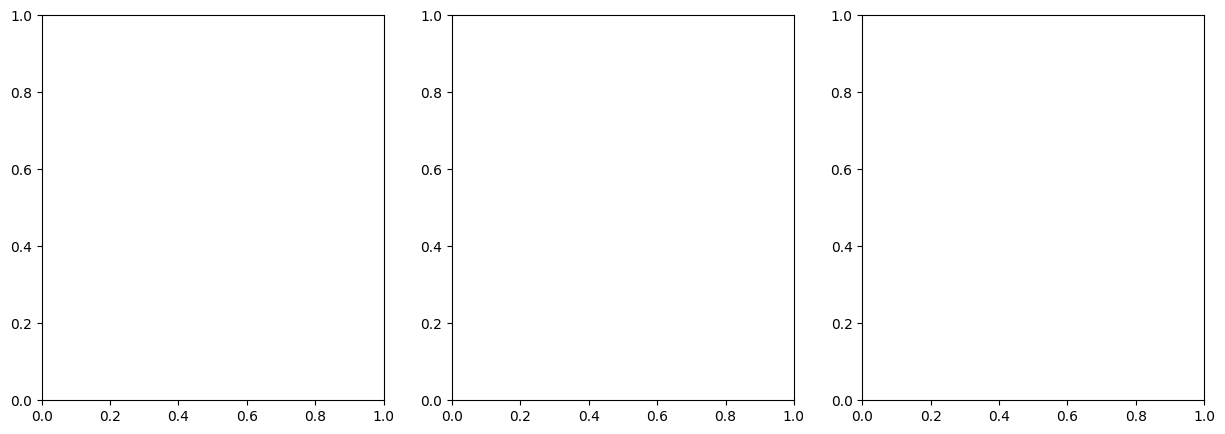

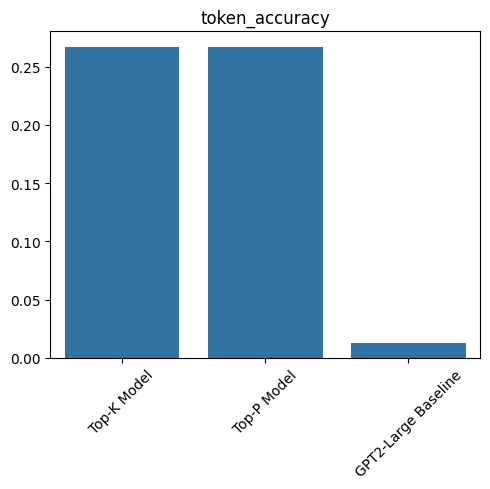

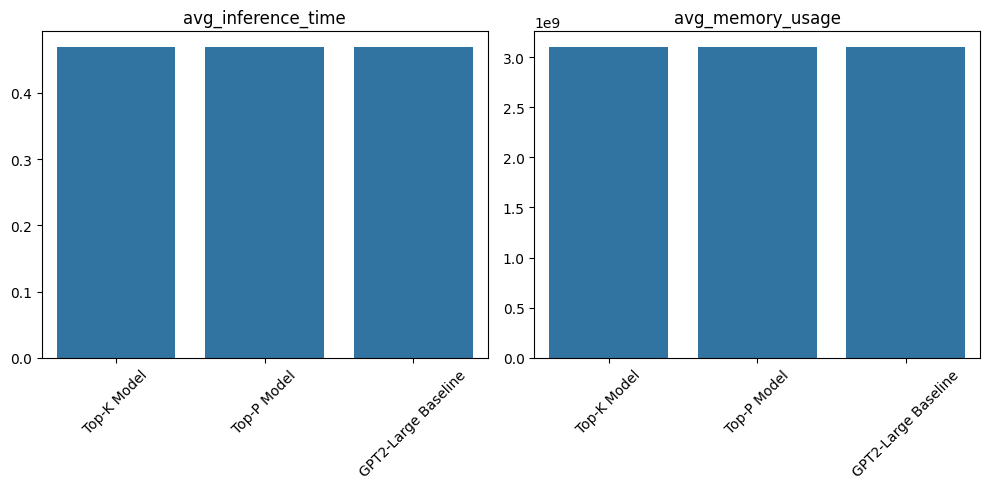

<Figure size 640x480 with 0 Axes>

In [7]:
evaluator.print_results()  # Prints formatted table
evaluator.plot_results()   # Shows plots

In [9]:
# Load a subset of the C4 dataset
from datasets import load_dataset
import random

def load_diverse_dataset(num_samples=1000, seed=42):
    # Load C4 dataset
    dataset = load_dataset(
        "c4", 
        "en", 
        split="train", 
        streaming=True
    )
    
    # Set seed for reproducibility
    random.seed(seed)
    
    # Sample diverse texts
    samples = []
    seen_domains = set()
    
    # Keep track of samples per complexity level
    simple_count = 0
    medium_count = 0
    complex_count = 0
    
    for sample in dataset:
        text = sample['text']
        
        # Skip very short texts
        if len(text.split()) < 50:
            continue
            
        # Estimate text complexity based on features
        avg_word_length = sum(len(word) for word in text.split()) / len(text.split())
        sentence_count = text.count('.') + text.count('!') + text.count('?')
        words_per_sentence = len(text.split()) / max(1, sentence_count)
        
        # Classify complexity
        if avg_word_length < 4.5 and words_per_sentence < 15:
            complexity = 'simple'
            if simple_count >= num_samples // 3:
                continue
            simple_count += 1
        elif avg_word_length > 6 or words_per_sentence > 25:
            complexity = 'complex'
            if complex_count >= num_samples // 3:
                continue
            complex_count += 1
        else:
            complexity = 'medium'
            if medium_count >= num_samples // 3:
                continue
            medium_count += 1
        
        samples.append({
            'text': text,
            'complexity': complexity,
            'avg_word_length': avg_word_length,
            'words_per_sentence': words_per_sentence
        })
        
        if len(samples) >= num_samples:
            break
    
    # Convert to dataset
    from datasets import Dataset
    return Dataset.from_dict({
        'text': [s['text'] for s in samples],
        'complexity': [s['complexity'] for s in samples],
        'metrics': [{
            'avg_word_length': s['avg_word_length'],
            'words_per_sentence': s['words_per_sentence']
        } for s in samples]
    })

# Load the dataset
dataset = load_diverse_dataset(num_samples=300)  # Smaller sample size for testing
print("\nDataset complexity distribution:")
print(dataset.features['complexity'].value_counts())

# Print some statistics
complexities = dataset['complexity']
print("\nSample counts:")
for complexity in ['simple', 'medium', 'complex']:
    count = sum(1 for c in complexities if c == complexity)
    print(f"{complexity}: {count} samples ({count/len(complexities)*100:.1f}%)")

/home/ec2-user/.cache/huggingface/modules/datasets_modules/datasets/c4/584d57ebe81c209b6c7f31727066d2c4b4bba37cb7092cdd83083d5ec11207db/c4.py:53: FutureWarning: Dataset 'c4' is deprecated and will be deleted. Use 'allenai/c4' instead.
  warnings.warn(
INFO:datasets_modules.datasets.c4.584d57ebe81c209b6c7f31727066d2c4b4bba37cb7092cdd83083d5ec11207db.c4:generating examples from = https://huggingface.co/datasets/allenai/c4/resolve/1ddc917116b730e1859edef32896ec5c16be51d0/en/c4-train.00000-of-01024.json.gz



Dataset complexity distribution:


AttributeError: 'Value' object has no attribute 'value_counts'

In [1]:
from evaluation_c4 import C4Evaluator

evaluator = C4Evaluator(
    models={
        "Top-K Model": "stevensu123/gpt2-moe-topk",
        "Top-P Model": "stevensu123/gpt2-moe-topp",
        "GPT2-Large Baseline": "gpt2-large"
    },
    num_samples=1000,  # Number of samples to evaluate
    batch_size=8,      # Batch size for processing
    max_length=512     # Maximum sequence length
)

/home/ec2-user/dynamic_moe/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:evaluation_c4:Loading C4 dataset...
/home/ec2-user/.cache/huggingface/modules/datasets_modules/datasets/c4/584d57ebe81c209b6c7f31727066d2c4b4bba37cb7092cdd83083d5ec11207db/c4.py:53: FutureWarning: Dataset 'c4' is deprecated and will be deleted. Use 'allenai/c4' instead.
  warnings.warn(
INFO:datasets_modules.datasets.c4.584d57ebe81c209b6c7f31727066d2c4b4bba37cb7092cdd83083d5ec11207db.c4:generating examples from = https://huggingface.co/datasets/allenai/c4/resolve/1ddc917116b730e1859edef32896ec5c16be51d0/en/c4-train.00000-of-01024.json.gz
INFO:evaluation_c4:Loaded 1000 samples from C4 dataset


In [3]:
results = evaluator.evaluate_all()

INFO:evaluation_c4:Evaluating Top-K Model...
ERROR:evaluation_c4:Error loading model your-model-id-1: your-model-id-1 is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`
ERROR:evaluation_c4:Error evaluating Top-K Model: your-model-id-1 is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`
INFO:evaluation_c4:Evaluating Top-P Model...
ERROR:evaluation_c4:Error loading model your-model-id-2: your-model-id-2 is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pa

In [ ]:
evaluator.print_results()  # Prints formatted table
evaluator.plot_results()   # Shows plots